# FCR-N prequalification study with HydroPowerDynamics.jl

This notebook is an engineering preparation tool for Nordic/Statnett FCR-N prequalification.
It does not replace the formal TSO test or the Nordic prequalification tool.

The workflow is deliberately simple:

`official FCR-N test definition -> linear screening -> JuMP capacity search -> frequency-domain checks -> nonlinear HPD replay -> decision support`.

The plant is Trollheim-inspired and not a field-verified Trollheim model.

In [1]:
using HydroPowerDynamics
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using ModelingToolkitStandardLibrary
using ModelingToolkitStandardLibrary.Blocks
using OrdinaryDiffEq
using ControlSystemsBase
using JuMP, Ipopt
using DataFrames, CSV
using Plots
using LinearAlgebra, Statistics, Printf

default(size=(840,470), linewidth=2, legend=:best)
plotdir = joinpath(@__DIR__, "plots")
resultdir = joinpath(@__DIR__, "results")
mkpath(plotdir); mkpath(resultdir)
println("Statnett-aligned FCR-N study loaded")

[ Info: Precompiling HydroPowerDynamics [3b6e4b0c-9b3e-4e2f-8c1a-7f2d5e6a9b4c] (cache misses: target mismatch (2))


┌ Warning: the bare singleton variant syntax `ContinuousClock` is deprecated, write `ContinuousClock()` instead (near /home/runner/.julia/packages/SciMLBase/O1HPI/src/clock.jl:4)
│   caller = eval at boot.jl:430 [inlined]
└ @ Core ./boot.jl:430


┌ Warning: the bare singleton variant syntax `Inferred` is deprecated, write `Inferred()` instead (near /home/runner/.julia/packages/ModelingToolkit/JvjlW/src/clock.jl:2)
│   caller = eval at boot.jl:430 [inlined]
└ @ Core ./boot.jl:430


[ Info: Precompiling ControlSystemsBase [aaaaaaaa-a6ca-5380-bf3e-84a91bcd477e] (cache misses: target mismatch (2))


[ Info: Precompiling PolynomialsChainRulesCoreExt [f5ad5175-ea71-5bad-b0d8-3d77b6894ccb] (cache misses: target mismatch (2))


...

[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] (cache misses: target mismatch (2))


[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: target mismatch (2))


[ Info: Precompiling UnitfulExt [0e51ec96-f580-5f12-a625-1297083d7970] (cache misses: target mismatch (2))


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: target mismatch (2))


Statnett-aligned FCR-N study loaded


## 1. Well-posed engineering question

We want the largest FCR-N capacity that this hydro unit can prepare to offer at the selected operating point,
while respecting the Nordic FCR-N activation band, the official step sequence, the steady-state response envelope,
the Nordic frequency-domain stability/performance checks, and plant-specific guide-vane/flow limits.

The optimizer is used only to reduce trial-and-error. The final formal prequalification still requires the prescribed tests,
logged data, TSO evaluation and application.

In [2]:
const PBASE_MW = 150.0
const P0_MW = 75.0
const F0_HZ = 50.0
const DF_FCRN_HZ = 0.10
const POLES = 16
const W0 = 2π*(120F0_HZ/POLES)/60
const H_GROSS = 371.0
const RHO = 1000.0
const G = 9.81
const P_ATM = 101325.0
const P_UP = P_ATM + RHO*G*H_GROSS
const Q0 = 22.13749950628151
const DM0 = RHO*Q0
const Y0 = 0.5384797177203611
const L_HEADRACE = 500.0
const D_HEADRACE = 6.0
const L_PENSTOCK = 500.0
const D_PENSTOCK = 4.0
const ROUGHNESS = 1.5e-5
const D_RUNNER = 2.5
const Q_RATED = 37.0
const ETA_MAX = 0.97
const C_ETA = 0.25
const KQ = Q_RATED/(0.90*D_RUNNER^2*sqrt(H_GROSS))
const TG = 0.30

# Plant engineering limits. These are NOT Statnett limits.
const Y_MIN = 0.05
const Y_MAX = 1.00
const DY_OPEN = 0.12
const DY_CLOSE = 0.12
const Q_MIN_PU = 0.70
const Q_MAX_PU = 1.45
const CAP_MAX_MW = 30.0

A_hr = π*D_HEADRACE^2/4
A_ps = π*D_PENSTOCK^2/4
Tw = L_HEADRACE*Q0/(G*A_hr*H_GROSS) + L_PENSTOCK*Q0/(G*A_ps*H_GROSS)
@printf("Operating point: P0=%.1f MW, Q0=%.4f m3/s, y0=%.4f pu\n", P0_MW,Q0,Y0)
@printf("Reduced-model water starting time Tw=%.4f s\n",Tw)

Operating point: P0=75.0 MW, Q0=22.1375 m3/s, y0=0.5385 pu
Reduced-model water starting time Tw=0.3496 s


## 2. Nordic FCR-N test definition used in this notebook

FCR-N is fully activated over 49.9-50.1 Hz. The official step sequence is represented below:
50.0 Hz -> 49.95 Hz pre-step -> 50.0 Hz -> 49.9 Hz -> 50.1 Hz -> 50.0 Hz.
The full-activation plateaus are held for 5 minutes here. The formal endurance case for a non-LER holds the relevant full-activation step for 15 minutes.

The steady-state test allows at most 5% under-delivery and 20% over-delivery relative to the theoretical FCR-N response.

In [3]:
function fcrn_step_frequency(ts)
    ts < 30      ? 50.0  :
    ts < 60      ? 49.95 :
    ts < 360     ? 50.0  :
    ts < 660     ? 49.9  :
    ts < 960     ? 50.1  :
                   50.0
end

step_breaks = [0.0,30.0,60.0,360.0,660.0,960.0,1260.0]
step_freqs = [50.0,49.95,50.0,49.9,50.1,50.0]
step_table = DataFrame(interval=["0-0.5 min","0.5-1 min","1-6 min","6-11 min","11-16 min","16-21 min"],
                       frequency_Hz=step_freqs,
                       purpose=["start","backlash pre-step","baseline","full upward FCR-N","full downward FCR-N","return to baseline"])
display(step_table)

Row,interval,frequency_Hz,purpose
,String,Float64,String
1,0-0.5 min,50.0,start
2,0.5-1 min,49.95,backlash pre-step
3,1-6 min,50.0,baseline
4,6-11 min,49.9,full upward FCR-N
5,11-16 min,50.1,full downward FCR-N
6,16-21 min,50.0,return to baseline


## 3. Reduced linear plant model

The screening model keeps the two dominant short-term states: normalized water flow deviation and guide-vane deviation.
The guide-vane command is normalized so that a full 0.1 Hz FCR-N activation requests the offered MW capacity, not an arbitrary gate increment.

Row,real,imag
,Float64,Float64
1,-2.86058,0.0
2,-3.33333,0.0


Row,period_s,omega_rad_s,F_mag,phase_deg
,Float64,Float64,Float64,Float64
1,10.0,0.628319,0.959814,156.937
2,15.0,0.418879,0.981727,164.507
3,25.0,0.251327,0.993343,170.667
4,40.0,0.15708,0.997389,174.159
5,50.0,0.125664,0.998327,175.326
6,60.0,0.10472,0.998838,176.104
7,70.0,0.0897598,0.999146,176.66
8,90.0,0.0698132,0.999483,177.402
9,150.0,0.0418879,0.999814,178.441


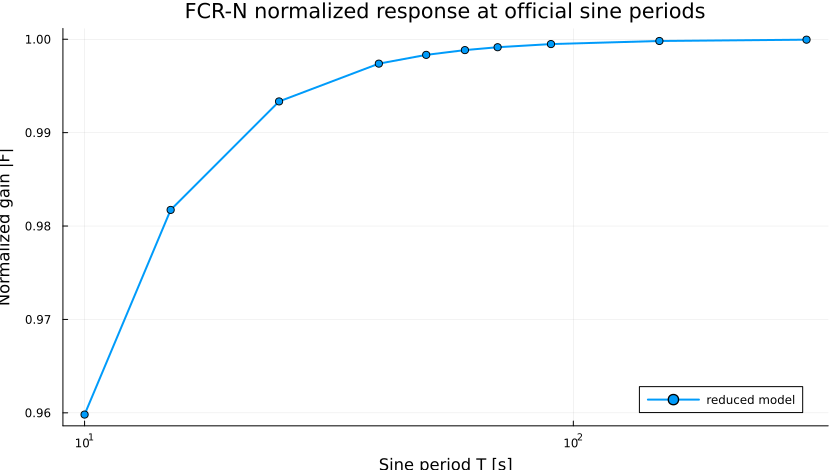

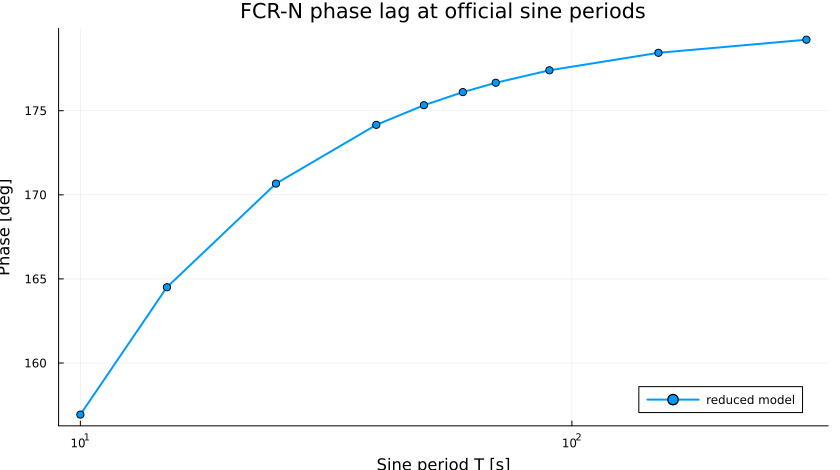

In [4]:
function reduced_ss(C_MW)
    Ky = Y0*(C_MW/P0_MW)/DF_FCRN_HZ
    A = [-1/Tw  1/(Tw*Y0); 0.0 -1/TG]
    B = [0.0; -Ky/TG]
    C = [P0_MW 0.0]
    Dm = [0.0]
    ss(A,B,C,Dm)
end

Cref = 1.0
Gref = reduced_ss(Cref)
λ = poles(Gref)
display(DataFrame(real=real.(λ),imag=imag.(λ)))

# Normalized entity transfer function F(jw): multiply MW/Hz response by 0.1 Hz / 1 MW.
periods = [10.0,15.0,25.0,40.0,50.0,60.0,70.0,90.0,150.0,300.0]
wtest = 2π ./ periods
Fpts = vec(freqresp(Gref,wtest)) .* (DF_FCRN_HZ/Cref)
freq_table = DataFrame(period_s=periods,
    omega_rad_s=wtest,
    F_mag=abs.(Fpts),
    phase_deg=rad2deg.(angle.(Fpts)))
display(freq_table)

p1 = plot(periods,abs.(Fpts),xscale=:log10,marker=:circle,xlabel="Sine period T [s]",ylabel="Normalized gain |F|",title="FCR-N normalized response at official sine periods",label="reduced model")
savefig(p1,joinpath(plotdir,"01_fcrn_sine_gain.png")); display(p1)

p2 = plot(periods,rad2deg.(angle.(Fpts)),xscale=:log10,marker=:circle,xlabel="Sine period T [s]",ylabel="Phase [deg]",title="FCR-N phase lag at official sine periods",label="reduced model")
savefig(p2,joinpath(plotdir,"02_fcrn_sine_phase.png")); display(p2)

## 4. Nordic frequency-domain stability and performance screening

The Nordic requirement builds a normalized open-loop response from the entity response F(jw) and a defined Nordic power-system model G(jw).
For FCR-N stability the reference system uses 600 MW FCR-N, 0.1 Hz one-sided band, Sn=23000 MW, H=5.2174 s and Kf=0.01 pu/Hz.
The Nyquist curve shall remain to the right of the exclusion circle around -1; the nominal radius is 0.43, with the stated 95% margin corresponding to 0.4085.

The performance check uses the FCR-N performance system parameters Sn=42000 MW and H=4.5238 s and the disturbance profile D(s)=1/(70s+1).

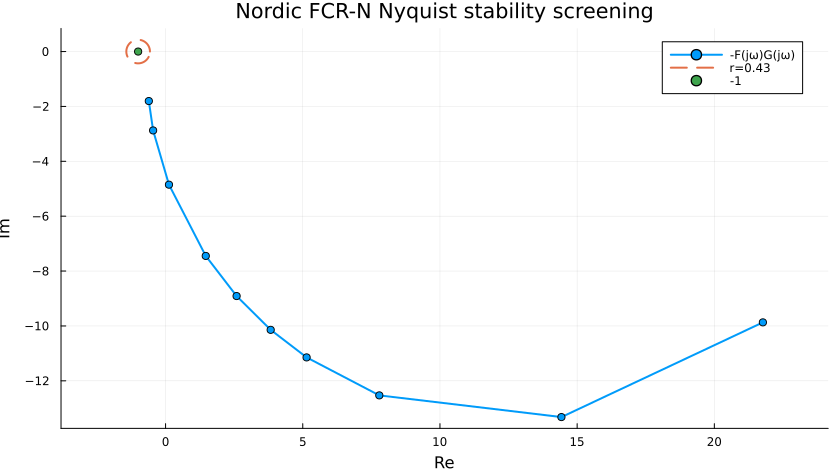

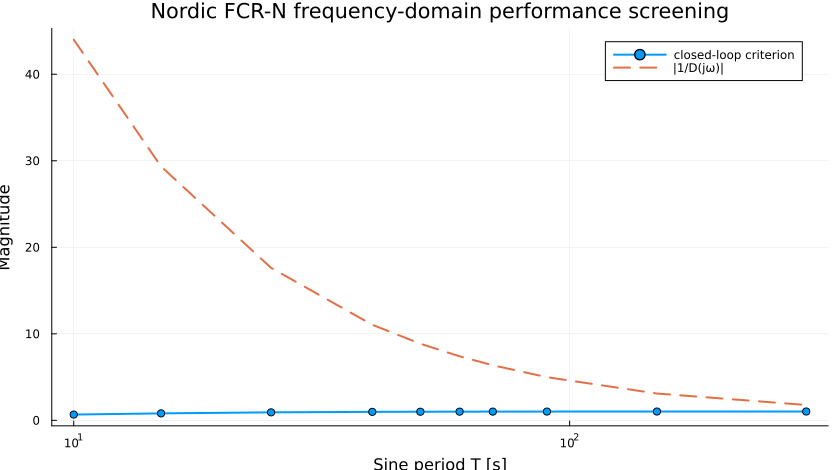

Nyquist minimum distance to -1 = 1.8450; nominal r=0.43 pass=true; 95% margin pass=true
Performance max criterion ratio = 0.5752; pass=true


In [5]:
function nordic_G(ω; Sn,H)
    dP = 600.0; df = 0.1; f0=50.0; Kf=0.01
    (dP/df)*(f0/Sn) / (2H*(im*ω) + Kf*f0)
end
Gstab = [nordic_G(ω;Sn=23000.0,H=5.2174) for ω in wtest]
Gperf = [nordic_G(ω;Sn=42000.0,H=4.5238) for ω in wtest]
G0 = -Fpts .* Gstab
nyq_dist = abs.(G0 .+ 1)
min_dist = minimum(nyq_dist)
pass_stab_nominal = min_dist >= 0.43
pass_stab_95 = min_dist >= 0.43*0.95

θ = range(0,2π,length=300)
p3 = plot(real.(G0),imag.(G0),marker=:circle,xlabel="Re",ylabel="Im",title="Nordic FCR-N Nyquist stability screening",label="-F(jω)G(jω)",aspect_ratio=:equal)
plot!(p3,-1 .+ 0.43*cos.(θ),0.43*sin.(θ),linestyle=:dash,label="r=0.43")
scatter!(p3,[-1.0],[0.0],label="-1")
savefig(p3,joinpath(plotdir,"03_fcrn_nyquist_requirement8.png")); display(p3)

Kmargin = 0.95
Gc_mag = Kmargin .* abs.(Gperf ./ (1 .+ Fpts .* Gperf))
requirement_mag = abs.(1 .+ 70im .* wtest)
perf_ratio = Gc_mag ./ requirement_mag
pass_perf = maximum(perf_ratio) < 1.0
p4 = plot(periods,Gc_mag,xscale=:log10,marker=:circle,xlabel="Sine period T [s]",ylabel="Magnitude",title="Nordic FCR-N frequency-domain performance screening",label="closed-loop criterion")
plot!(p4,periods,requirement_mag,linestyle=:dash,label="|1/D(jω)|")
savefig(p4,joinpath(plotdir,"04_fcrn_performance_requirement9.png")); display(p4)

@printf("Nyquist minimum distance to -1 = %.4f; nominal r=0.43 pass=%s; 95%% margin pass=%s\n",min_dist,string(pass_stab_nominal),string(pass_stab_95))
@printf("Performance max criterion ratio = %.4f; pass=%s\n",maximum(perf_ratio),string(pass_perf))

## 5. JuMP capacity search using the official FCR-N step sequence

Decision variable: maintained FCR-N capacity C [MW].

The reduced dynamics are enforced over the full 21-minute step sequence. The optimization also enforces:
- the Nordic steady-state response envelope at 49.9 and 50.1 Hz,
- plant guide-vane position and rate limits,
- plant flow limits.

The guide-vane and flow limits are plant assumptions, not TSO rules.


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

JuMP status=LOCALLY_SOLVED
FCR-N candidate=2.5071 MW


Power-base droop interpretation=11.9662%; controller R=0.111111 pu/pu
Linear steady up=2.5071 MW; steady down=-2.5071 MW; max gate rate=0.1200 pu/s


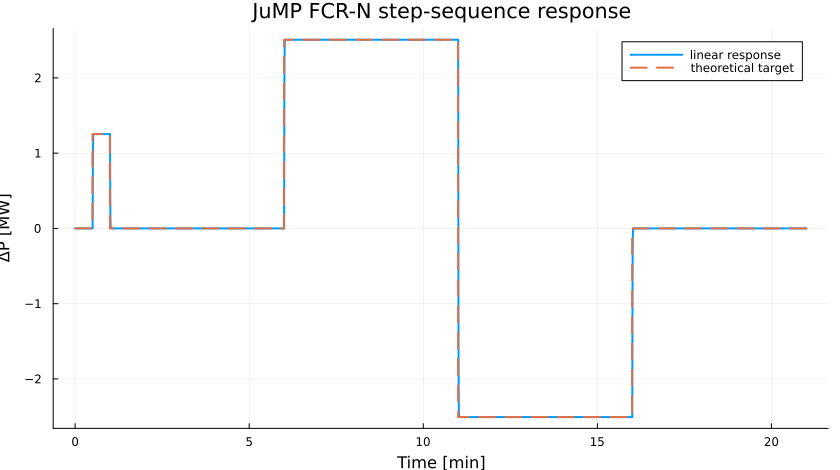

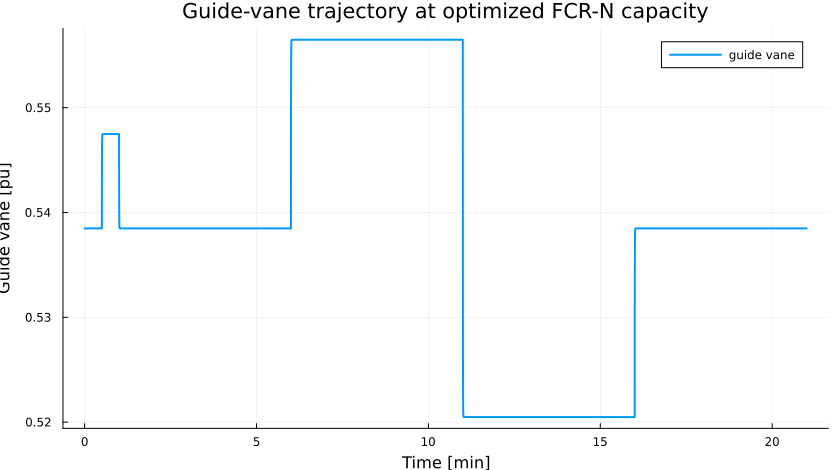

In [6]:
dt = 0.2
times = collect(0.0:dt:1260.0)
N = length(times)
freq = fcrn_step_frequency.(times)
activation = (F0_HZ .- freq)./DF_FCRN_HZ

m = Model(Ipopt.Optimizer); set_silent(m)
@variable(m,0 <= C_FCRN <= CAP_MAX_MW)
@variable(m,Y_MIN <= y[1:N] <= Y_MAX)
@variable(m,Q_MIN_PU <= q[1:N] <= Q_MAX_PU)
@constraint(m,y[1] == Y0)
@constraint(m,q[1] == 1.0)
for k in 1:N-1
    ycmd = Y0*(1 + (C_FCRN/P0_MW)*activation[k])
    @constraint(m,y[k+1] == y[k] + dt/TG*(ycmd-y[k]))
    @constraint(m,q[k+1] == q[k] + dt/Tw*(y[k]/Y0-q[k]))
    @constraint(m,y[k+1]-y[k] <= DY_OPEN*dt)
    @constraint(m,y[k]-y[k+1] <= DY_CLOSE*dt)
end

k_up = argmin(abs.(times .- 650.0))
k_dn = argmin(abs.(times .- 950.0))
dP_up = P0_MW*(q[k_up]-1)
dP_dn = P0_MW*(q[k_dn]-1)
@constraint(m,0.95*C_FCRN <= dP_up)
@constraint(m,dP_up <= 1.20*C_FCRN)
@constraint(m,-1.20*C_FCRN <= dP_dn)
@constraint(m,dP_dn <= -0.95*C_FCRN)
@objective(m,Max,C_FCRN)
optimize!(m)

Cstar = value(C_FCRN); yv=value.(y); qv=value.(q); dPv=P0_MW.*(qv.-1)
rate=diff(yv)./dt

# Two droop quantities are intentionally reported.
# Rpower is a conventional power-base interpretation for decision makers.
# Rctrl is the internal gate-controller R used by SimpleGovernorAGC, whose output is absolute gate pu.
Rpower = (DF_FCRN_HZ/F0_HZ)/(Cstar/PBASE_MW)
Rctrl = (DF_FCRN_HZ/F0_HZ)/(Y0*Cstar/P0_MW)

@printf("JuMP status=%s\n",string(termination_status(m)))
@printf("FCR-N candidate=%.4f MW\n",Cstar)
@printf("Power-base droop interpretation=%.4f%%; controller R=%.6f pu/pu\n",100Rpower,Rctrl)
@printf("Linear steady up=%.4f MW; steady down=%.4f MW; max gate rate=%.4f pu/s\n",dPv[k_up],dPv[k_dn],maximum(abs.(rate)))

p5 = plot(times./60,dPv,xlabel="Time [min]",ylabel="ΔP [MW]",title="JuMP FCR-N step-sequence response",label="linear response")
plot!(p5,times./60,Cstar.*activation,linestyle=:dash,label="theoretical target")
savefig(p5,joinpath(plotdir,"05_jump_fcrn_step_response.png")); display(p5)

p6 = plot(times./60,yv,xlabel="Time [min]",ylabel="Guide vane [pu]",title="Guide-vane trajectory at optimized FCR-N capacity",label="guide vane")
savefig(p6,joinpath(plotdir,"06_jump_fcrn_gate.png")); display(p6)

## 6. Full nonlinear HydroPowerDynamics.jl replay of the FCR-N step test

The optimized candidate is mapped to the HPD governor and the same FCR-N frequency sequence is injected at a prescribed shaft-frequency boundary.
We calculate steady response from the last 60 s of the 49.9 Hz and 50.1 Hz plateaus.

┌ Warning: shaft contains 1 flow variables, yet 2 regular (non-flow, non-stream, non-input, non-output) variables. This could lead to imbalanced model that are difficult to debug. Consider marking some of the regular variables as input/output variables.
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/systems/connectors.jl:153
┌ Warning: flange contains 1 flow variables, yet 2 regular (non-flow, non-stream, non-input, non-output) variables. This could lead to imbalanced model that are difficult to debug. Consider marking some of the regular variables as input/output variables.
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/systems/connectors.jl:153


┌ Warning: Initialization system is overdetermined. 3 equations for 2 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/problems/initializationproblem.jl:106


Nonlinear HPD retcode=Success; t_end=1260.0 s


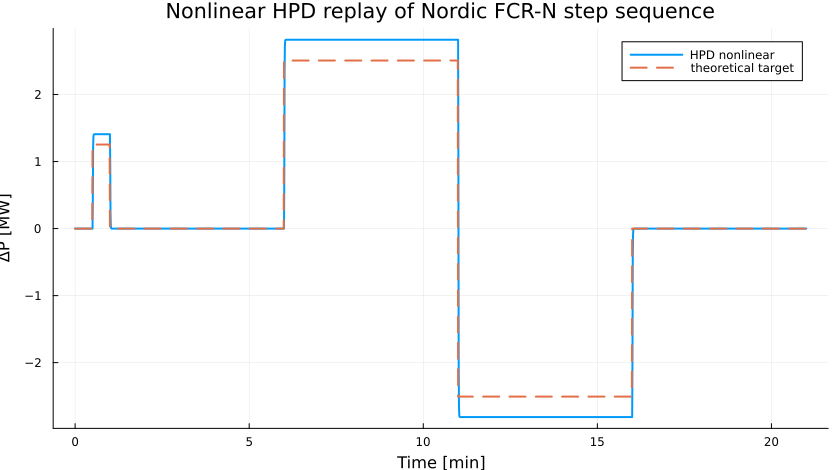

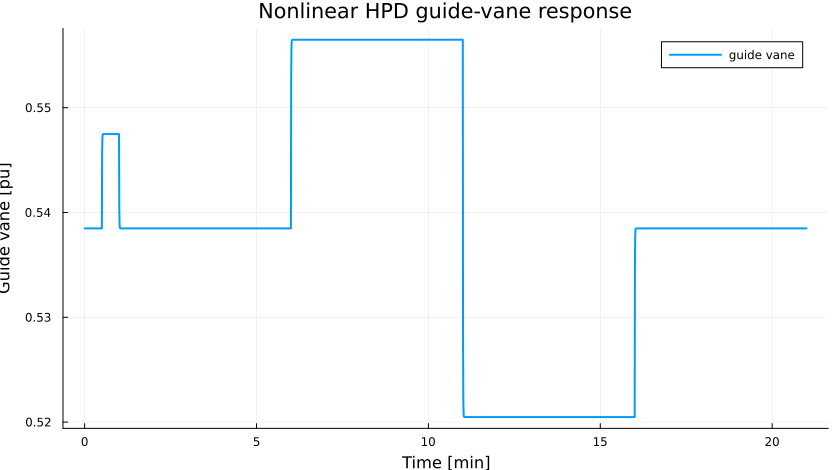

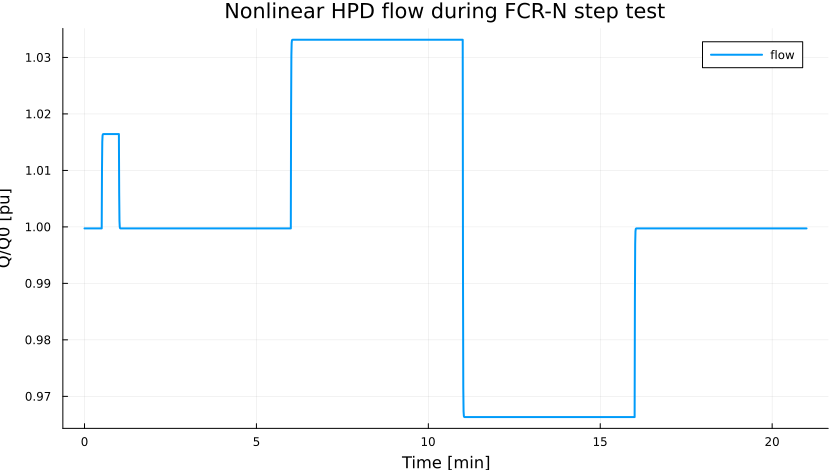

In [7]:
@mtkmodel PrescribedSpeedBoundary begin
    @components begin
        speed_in = Blocks.RealInput()
        flange = RotationalPort()
    end
    @variables begin
        phi(t)
    end
    @equations begin
        flange.omega ~ speed_in.u
        flange.phi ~ phi
        D(phi) ~ speed_in.u
    end
end

function pipe_guess(L,Dpipe)
    Ap=π*Dpipe^2/4; μ=1e-3
    Re=DM0*Dpipe/(μ*Ap)
    fD=1/(2log10(ROUGHNESS/(3.7Dpipe)+5.7/Re^0.9))^2
    dpf=fD*(L/Dpipe)*(DM0/(RHO*Ap))^2*RHO/2
    (;Re,fD,dpf)
end
HRG=pipe_guess(L_HEADRACE,D_HEADRACE); PNG=pipe_guess(L_PENSTOCK,D_PENSTOCK)
ETA0=ETA_MAX*(1-C_ETA*(Q0/Q_RATED-1)^2); TAU_SHAFT0=P0_MW*1e6/W0

function build_nonlinear_fcrn(Rdroop)
    @named upper=Reservoir(H=H_GROSS,rho=RHO,g=G,p_atm=P_ATM)
    @named tail=Reservoir(H=0.0,rho=RHO,g=G,p_atm=P_ATM)
    @named headrace=Penstock(L=L_HEADRACE,D_pipe=D_HEADRACE,rho=RHO,B=2e9,e=ROUGHNESS)
    @named penstock=Penstock(L=L_PENSTOCK,D_pipe=D_PENSTOCK,rho=RHO,B=2e9,e=ROUGHNESS)
    @named turbine=FrancisTurbineAffinity(D=D_RUNNER,K_q=KQ,eta_max=ETA_MAX,c_eta=C_ETA,Q_rated=Q_RATED,rho=RHO,g=G)
    @named governor=SimpleGovernorAGC(R=Rdroop,T_g=TG,K_i=0.0,omega_ref=W0,gate_bias=Y0,gate_min=Y_MIN,gate_max=Y_MAX)
    @named speedbc=PrescribedSpeedBoundary()
    ftest = ifelse(t < 0.0,F0_HZ,
            ifelse(t < 30.0,50.0,
            ifelse(t < 60.0,49.95,
            ifelse(t < 360.0,50.0,
            ifelse(t < 660.0,49.9,
            ifelse(t < 960.0,50.1,50.0))))))
    ωtest=W0*ftest/F0_HZ
    eqs=[connect(upper.port,headrace.port_a),connect(headrace.port_b,penstock.port_a),connect(penstock.port_b,turbine.port_in),connect(turbine.port_out,tail.port),connect(governor.gate_out,turbine.opening),connect(turbine.shaft,speedbc.flange),governor.speed_in.u~ωtest,speedbc.speed_in.u~ωtest]
    raw=ODESystem(eqs,t;name=:FCRN_Nonlinear,systems=[upper,tail,headrace,penstock,turbine,governor,speedbc])
    sys=structural_simplify(raw)
    (;sys,headrace,penstock,turbine,governor,speedbc)
end

nl=build_nonlinear_fcrn(Rctrl)
u0=Dict(nl.headrace.dm=>DM0,nl.penstock.dm=>DM0,nl.governor.xi=>0.0,nl.governor.gate=>Y0,nl.speedbc.phi=>0.0)
guesses=Dict(nl.headrace.p_avg=>P_UP,nl.headrace.Re=>HRG.Re,nl.headrace.f_D=>HRG.fD,nl.headrace.dp_f=>HRG.dpf,nl.penstock.p_avg=>P_UP,nl.penstock.Re=>PNG.Re,nl.penstock.f_D=>PNG.fD,nl.penstock.dp_f=>PNG.dpf,nl.turbine.H=>H_GROSS,nl.turbine.Q=>Q0,nl.turbine.eta=>ETA0,nl.turbine.P_mech=>P0_MW*1e6,nl.turbine.dm=>DM0,nl.turbine.tau_shaft=>TAU_SHAFT0)
prob=ODEProblem(nl.sys,u0,(-100.0,1260.0);guesses=guesses)
sol=solve(prob,Rodas5P();abstol=1e-7,reltol=1e-7,saveat=0.5,tstops=step_breaks)
@printf("Nonlinear HPD retcode=%s; t_end=%.1f s\n",string(sol.retcode),sol.t[end])

tv=sol.t; keep=findall(>=(0.0),tv); tt=tv[keep]
pm=sol[nl.turbine.P_mech][keep]./1e6; gate_nl=sol[nl.governor.tau_o][keep]; q_nl=sol[nl.turbine.Q][keep]
base_idx=findall(x->300<=x<360,tt); up_idx=findall(x->600<=x<660,tt); dn_idx=findall(x->900<=x<960,tt); end_idx=findall(x->1200<=x<=1260,tt)
Pbase=mean(pm[base_idx]); Pup=mean(pm[up_idx]); Pdn=mean(pm[dn_idx]); Pend=mean(pm[end_idx])
Pref=0.5*(Pbase+Pend)
ΔPup=Pup-Pref; ΔPdn=Pdn-Pref
up_ratio=ΔPup/Cstar; dn_ratio=abs(ΔPdn)/Cstar
pass_ss_up = 0.95 <= up_ratio <= 1.20
pass_ss_dn = 0.95 <= dn_ratio <= 1.20
rate_nl=diff(gate_nl)./diff(tt)
pass_gate = minimum(gate_nl)>=Y_MIN-1e-6 && maximum(gate_nl)<=Y_MAX+1e-6
pass_flow = minimum(q_nl)/Q0>=Q_MIN_PU-1e-3 && maximum(q_nl)/Q0<=Q_MAX_PU+1e-3
pass_rate = maximum(rate_nl)<=DY_OPEN+2e-3 && minimum(rate_nl)>=-DY_CLOSE-2e-3

p7=plot(tt./60,pm.-Pref,xlabel="Time [min]",ylabel="ΔP [MW]",title="Nonlinear HPD replay of Nordic FCR-N step sequence",label="HPD nonlinear")
plot!(p7,tt./60,Cstar.*((F0_HZ .- fcrn_step_frequency.(tt))./DF_FCRN_HZ),linestyle=:dash,label="theoretical target")
savefig(p7,joinpath(plotdir,"07_nonlinear_fcrn_step_response.png")); display(p7)

p8=plot(tt./60,gate_nl,xlabel="Time [min]",ylabel="Guide vane [pu]",title="Nonlinear HPD guide-vane response",label="guide vane")
savefig(p8,joinpath(plotdir,"08_nonlinear_fcrn_gate.png")); display(p8)

p9=plot(tt./60,q_nl./Q0,xlabel="Time [min]",ylabel="Q/Q0 [pu]",title="Nonlinear HPD flow during FCR-N step test",label="flow")
savefig(p9,joinpath(plotdir,"09_nonlinear_fcrn_flow.png")); display(p9)

## 7. Decision table

`PASS - engineering preparation` means that this simulated candidate satisfies the implemented Nordic steady-state and frequency-domain checks plus the assumed plant limits.
It is not a Statnett approval. The real unit must still perform the formal test program with the required logging and application package.

In [8]:
engineering_pass = all((pass_ss_up,pass_ss_dn,pass_stab_95,pass_perf,pass_gate,pass_flow,pass_rate))
decision = engineering_pass ? "PASS - engineering preparation" : "REDUCE / RETUNE"
summary = DataFrame(
    metric=["JuMP FCR-N candidate [MW]","Power-base droop interpretation [%]","Internal controller R [pu/pu]","Nonlinear upward steady response [MW]","Nonlinear downward steady response [MW]","Upward response / offer","Downward response / offer","Nyquist min distance to -1","Requirement 8 nominal circle pass","Requirement 8 95% margin pass","Requirement 9 performance pass","Max guide vane [pu]","Max flow/Q0 [pu]","Max |gate rate| [pu/s]","Decision"],
    value=[@sprintf("%.4f",Cstar),@sprintf("%.4f",100Rpower),@sprintf("%.6f",Rctrl),@sprintf("%.4f",ΔPup),@sprintf("%.4f",ΔPdn),@sprintf("%.4f",up_ratio),@sprintf("%.4f",dn_ratio),@sprintf("%.4f",min_dist),string(pass_stab_nominal),string(pass_stab_95),string(pass_perf),@sprintf("%.4f",maximum(gate_nl)),@sprintf("%.4f",maximum(q_nl)/Q0),@sprintf("%.4f",maximum(abs.(rate_nl))),decision])
display(summary)

record=DataFrame(candidate_MW=[Cstar],power_droop_percent=[100Rpower],controller_R_pu=[Rctrl],nonlinear_up_MW=[ΔPup],nonlinear_down_MW=[ΔPdn],up_ratio=[up_ratio],down_ratio=[dn_ratio],nyquist_min_distance=[min_dist],req8_nominal_pass=[pass_stab_nominal],req8_margin95_pass=[pass_stab_95],req9_pass=[pass_perf],max_gate_pu=[maximum(gate_nl)],max_flow_pu=[maximum(q_nl)/Q0],max_gate_rate_pus=[maximum(abs.(rate_nl))],decision=[decision])
CSV.write(joinpath(resultdir,"fcr_candidate_summary.csv"),record)
traj=DataFrame(time_s=tt,frequency_Hz=fcrn_step_frequency.(tt),nonlinear_power_MW=pm,nonlinear_deltaP_MW=pm.-Pref,nonlinear_gate_pu=gate_nl,nonlinear_Q_m3s=q_nl)
CSV.write(joinpath(resultdir,"fcr_validation_trajectory.csv"),traj)
CSV.write(joinpath(resultdir,"fcr_frequency_domain.csv"),freq_table)
println("Final decision: ",decision)

Row,metric,value
,String,String
1,JuMP FCR-N candidate [MW],2.5071
2,Power-base droop interpretation [%],11.9662
3,Internal controller R [pu/pu],0.111111
4,Nonlinear upward steady response [MW],2.8169
5,Nonlinear downward steady response [MW],-2.8120
6,Upward response / offer,1.1236
7,Downward response / offer,1.1216
8,Nyquist min distance to -1,1.8450
9,Requirement 8 nominal circle pass,true


Final decision: PASS - engineering preparation

## 8. Practical interpretation

A control engineer should use the result in this order:
1. JuMP gives a candidate MW value and exposes the active plant constraint.
2. The Nordic sine-frequency checks ask whether the controller is fast enough without reducing system stability margin.
3. The nonlinear HPD step replay checks whether hydraulic physics changes the steady response enough to invalidate the candidate.
4. If the simulated candidate passes, it is worth taking to the physical prequalification test. If it fails, retune or derate before spending test time.

The next extension is to repeat the same architecture at all required operating points, add the 15-minute endurance case and measured-response linearity checks, and then extend to dynamic FCR-D up/down.